## Worked Example: Rock-Paper-Scissors
From the paper "An Introduction to Counterfactual Regret Minimization" by Todd W. Neller and Marc Lanctot, Section 2.4.

In [1]:
import numpy as np

np.random.seed(2)  # For reproducibility

In [2]:
# init action values for the actions
ROCK = 0
PAPER = 1
SCISSORS = 2

# number of actions in RPS
NUM_ACTIONS = 3

# initialize regret and strategy sums
regret_sum = np.zeros(NUM_ACTIONS)
strategy = np.zeros(NUM_ACTIONS)
strategy_sum = np.zeros(NUM_ACTIONS)
opp_strategy = [0.4, 0.3, 0.3]  # arbitrary

In [3]:
def get_strategy():
    """Get the current strategy based on regret matching."""
    normalizing_sum = 0

    # first pass to sum up the positive regrets
    for a in range(NUM_ACTIONS):
        strategy[a] = max(0, regret_sum[a])
        normalizing_sum += strategy[a]

    # second pass to normalize the strategy if any positive regrets exist, otherwise use uniform strategy
    for a in range(NUM_ACTIONS):
        if normalizing_sum > 0: # could be non-positive
            strategy[a] /= normalizing_sum
        else:
            strategy[a] = 1.0 / NUM_ACTIONS
        strategy_sum[a] += strategy[a]
    return strategy

In [4]:
def get_action(strategy):
    """Get an action based on the current strategy."""
    r = np.random.random()
    cumulative_probability = 0.0
    
    for a in range(NUM_ACTIONS):
        cumulative_probability += strategy[a]
        if r < cumulative_probability:
            return a
    return NUM_ACTIONS - 1  # fallback to last action

In [5]:
def get_average_strategy():
    """Get the average strategy over all iterations."""
    avg_strategy = np.zeros(NUM_ACTIONS)
    normalizing_sum =0
    
    for a in range(NUM_ACTIONS):
        normalizing_sum += strategy_sum[a]
    for a in range(NUM_ACTIONS):
        if normalizing_sum > 0:
            avg_strategy[a] = strategy_sum[a] / normalizing_sum
        else:
            avg_strategy[a] = 1.0 / NUM_ACTIONS
    return avg_strategy

In [6]:
## training algorithm
def train(iterations, log_interval=1000):
    """Train the RPS agent using regret matching."""
    action_utility = np.zeros(NUM_ACTIONS)
    history = np.zeros((iterations // log_interval, NUM_ACTIONS))  # to store actions for analysis

    for i in range(iterations):
        # get regret-matched mixed-strategy actions
        strategy = get_strategy()
        my_action = get_action(strategy)
        opp_action = get_action(opp_strategy)

        if i < 10:
            print(f"Initial action on iteration {i}: {my_action}, Opponent action: {opp_action}")

        # compute action utilities
        action_utility[opp_action] = 0 # if the opponent plays the same action, utility is 0
        action_utility[(opp_action + 1) % NUM_ACTIONS] = 1 # if the next action in RPS (winning action) is played, utility is 1
        action_utility[(opp_action - 1) % NUM_ACTIONS] = -1 # if the previous action in RPS (losing action) is played, utility is -1

        # accumulate action regrets
        for a in range(NUM_ACTIONS):
            regret_sum[a] += action_utility[a] - action_utility[my_action]
        if i % log_interval == 0:
            history[i // log_interval] = get_average_strategy().copy()  # store the action for analysis
    return history

In [7]:
history = train(1000000)
get_average_strategy()

Initial action on iteration 0: 1, Opponent action: 0
Initial action on iteration 1: 1, Opponent action: 1
Initial action on iteration 2: 1, Opponent action: 0
Initial action on iteration 3: 0, Opponent action: 1
Initial action on iteration 4: 1, Opponent action: 0
Initial action on iteration 5: 1, Opponent action: 1
Initial action on iteration 6: 1, Opponent action: 1
Initial action on iteration 7: 1, Opponent action: 2
Initial action on iteration 8: 1, Opponent action: 1
Initial action on iteration 9: 2, Opponent action: 0


array([1.33333333e-06, 9.99996583e-01, 2.08333333e-06])

## plotting

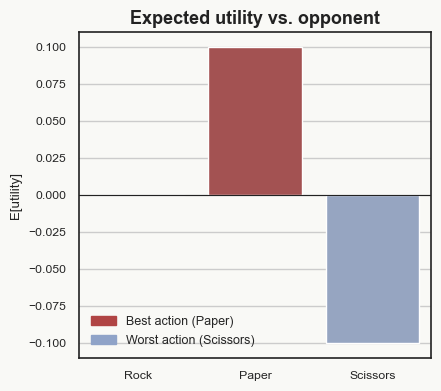

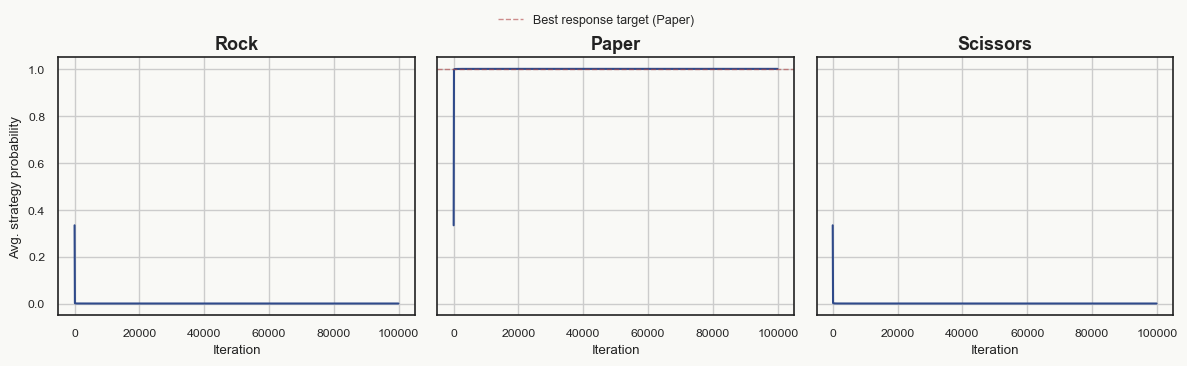

In [8]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

OFF_WHITE = "#F9F9F6"
INK = "#222222"
BLUE = "#2F4A8A"
RED = "#B04444"

sns.set_theme(
    style="whitegrid",
    font_scale=0.8,
    rc={'figure.facecolor': OFF_WHITE, 'axes.facecolor': OFF_WHITE}
)

labels = ["Rock", "Paper", "Scissors"]

payoff = np.array([
    [ 0,  -1,  1],
    [ 1,   0, -1],
    [-1,   1,  0],
])
expected_utility = payoff @ opp_strategy
best_idx = np.argmax(expected_utility)
worst_idx = np.argmin(expected_utility)
bar_colors = [RED if i == best_idx else "#8FA3C8" for i in range(NUM_ACTIONS)]

iters = np.arange(len(history)) * 100

# Figure 1: expected utility bar chart
fig1, ax1 = plt.subplots(figsize=(4.5, 4), facecolor=OFF_WHITE)
ax1.set_facecolor(OFF_WHITE)
sns.barplot(x=labels, y=expected_utility, ax=ax1, palette=bar_colors, hue=labels, legend=False)
ax1.axhline(0, color=INK, linewidth=0.8)
ax1.set_title("Expected utility vs. opponent", fontsize=13, fontweight="bold", color=INK)
ax1.set_ylabel("E[utility]", color=INK)
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color(INK)

if expected_utility[best_idx] >= 0.001:
    best_patch = mpatches.Patch(color=RED, label=f"Best action ({labels[best_idx]})")
    worst_patch = mpatches.Patch(color="#8FA3C8", label=f"Worst action ({labels[worst_idx]})")
    ax1.legend(handles=[best_patch, worst_patch], frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# Figure 2: strategy convergence, faceted by action
fig2, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True, facecolor=OFF_WHITE)
for i, label in enumerate(labels):
    ax = axes[i]
    ax.set_facecolor(OFF_WHITE)
    ax.plot(iters, history[:, i], color=BLUE, linewidth=1.5)
    if expected_utility[i] >= 0.001 and i == best_idx:
        ax.axhline(1.0, color=RED, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(label, fontsize=13, fontweight="bold", color=INK)
    ax.set_xlabel("Iteration", color=INK)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color(INK)

axes[0].set_ylabel("Avg. strategy probability", color=INK)

if expected_utility[best_idx] >= 0.001:
    target_line = mlines.Line2D([], [], color=RED, linestyle="--", linewidth=1, alpha=0.6,
                                  label=f"Best response target ({labels[best_idx]})")
    fig2.legend(handles=[target_line], frameon=False, fontsize=9, loc="upper center", ncol=1, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()